### INT D 491 EDA

In [1]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("cleaned_data_files")

csv_paths = sorted(DATA_DIR.rglob("*.csv"))
print(f"Found {len(csv_paths)} CSV files")

dfs = {}
for p in csv_paths:
    key = p.relative_to(DATA_DIR).as_posix()
    dfs[key] = pd.read_csv(p)

Found 54 CSV files


In [2]:
import numpy as np

rows = []
for name, df in dfs.items():
    rows.append({
        "file": name,
        "rows": len(df),
        "cols": df.shape[1],
        "missing_cells_%": round(df.isna().to_numpy().mean() * 100, 2),
        "duplicate_rows": int(df.duplicated().sum()),
        "num_cols": int(df.select_dtypes(include=np.number).shape[1]),
        "cat_cols": int(df.select_dtypes(include=["object","category","bool"]).shape[1]),
    })

summary = pd.DataFrame(rows).sort_values(["rows","cols"], ascending=False)
summary

,file,rows,cols,missing_cells_%,duplicate_rows,num_cols,cat_cols
5,cleaned_2550_f_u/adults_2550_female_urban_0400...,214849,17,0.0,0,10,7
7,cleaned_2550_f_u/adults_2550_female_urban_1200...,211152,17,0.0,0,10,7
14,cleaned_2550_m_u/adults_2550_male_urban_0000-0...,193048,17,0.0,0,10,7
6,cleaned_2550_f_u/adults_2550_female_urban_0800...,192092,17,0.0,0,10,7
8,cleaned_2550_f_u/adults_2550_female_urban_1600...,189213,17,0.0,0,10,7
4,cleaned_2550_f_u/adults_2550_female_urban_0000...,184248,17,0.0,0,10,7
15,cleaned_2550_m_u/adults_2550_male_urban_0400-0...,173963,17,0.0,0,10,7
18,cleaned_2550_m_u/adults_2550_male_urban_1600-1...,172543,17,0.0,0,10,7
16,cleaned_2550_m_u/adults_2550_male_urban_0800-1...,168215,17,0.0,0,10,7
17,cleaned_2550_m_u/adults_2550_male_urban_1200-1...,163782,17,0.0,0,10,7


In [3]:
name = summary.iloc[0]["file"]
df = dfs[name]
name, df.shape

('cleaned_2550_f_u/adults_2550_female_urban_0400-0799_clean.csv', (214849, 17))

In [4]:
df.head()
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214849 entries, 0 to 214848
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   cc_num          214849 non-null  int64  
 1   gender          214849 non-null  object 
 2   city            214849 non-null  object 
 3   state           214849 non-null  object 
 4   zip             214849 non-null  int64  
 5   lat             214849 non-null  float64
 6   long            214849 non-null  float64
 7   city_pop        214849 non-null  int64  
 8   job             214849 non-null  object 
 9   category        214849 non-null  object 
 10  amt             214849 non-null  float64
 11  is_fraud        214849 non-null  int64  
 12  merchant        214849 non-null  object 
 13  merch_lat       214849 non-null  float64
 14  merch_long      214849 non-null  float64
 15  trans_datetime  214849 non-null  object 
 16  age             214849 non-null  int64  
dtypes: float64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cc_num,214849.0,NaN,NaN,NaN,382605684372977792.0,1252263125559038208.0,60400268763.0,30170864942698.0,347356748095732.0,4593777569198326.0,4989103909120302080.0
gender,214849,1,F,214849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,214849,83,Stone Mountain,7305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,214849,33,TX,29183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip,214849.0,NaN,NaN,NaN,54134.37753,27703.285123,1027.0,30083.0,55345.0,78239.0,99362.0
lat,214849.0,NaN,NaN,NaN,37.160012,4.833496,25.8141,33.7942,36.9375,40.9262,47.838
long,214849.0,NaN,NaN,NaN,-92.606769,14.515958,-122.1864,-98.3627,-90.2522,-80.6277,-71.6847
city_pop,214849.0,NaN,NaN,NaN,285972.506588,521621.118276,2552.0,17660.0,63473.0,222272.0,2906700.0
job,214849,79,International aid/development worker,6565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,214849,14,shopping_pos,24090,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = (df.isna().mean().sort_values(ascending=False) * 100)
missing.head(20)

cc_num            0.0
category          0.0
trans_datetime    0.0
merch_long        0.0
merch_lat         0.0
merchant          0.0
is_fraud          0.0
amt               0.0
job               0.0
gender            0.0
city_pop          0.0
long              0.0
lat               0.0
zip               0.0
state             0.0
city              0.0
age               0.0
dtype: float64

In [6]:
df["is_fraud"].value_counts()
df["is_fraud"].mean()  # fraud rate

0.003611839012515767

In [7]:
num_cols = ["amt", "age", "city_pop"]
df.groupby("is_fraud")[num_cols].describe().T

is_fraud                   0             1
amt      count  2.140730e+05  7.760000e+02
         mean   8.804358e+01  3.462488e+02
         std    1.435588e+02  3.589139e+02
         min    1.000000e+00  6.320000e+00
         25%    1.883000e+01  2.000500e+01
         50%    5.364000e+01  2.381250e+02
         75%    1.109800e+02  6.873275e+02
         max    1.307389e+04  1.213960e+03
age      count  2.140730e+05  7.760000e+02
         mean   3.186180e+01  3.207345e+01
         std    7.249050e+00  7.029231e+00
         min    1.800000e+01  1.900000e+01
         25%    2.500000e+01  2.500000e+01
         50%    3.300000e+01  3.300000e+01
         75%    3.800000e+01  3.800000e+01
         max    4.400000e+01  4.300000e+01
city_pop count  2.140730e+05  7.760000e+02
         mean   2.860727e+05  2.583448e+05
         std    5.218260e+05  4.611040e+05
         min    2.552000e+03  2.552000e+03
         25%    1.766000e+04  1.766000e+04
         50%    6.347300e+04  4.105600e+04
         75%    2.222720e+05  2.567890e+05
         max    2.906700e+06  2.906700e+06

In [8]:
DATA_DIR = Path("cleaned_data_files")

csv_paths = sorted(DATA_DIR.rglob("*.csv"))
print("CSV files found:", len(csv_paths))

dfs = [pd.read_csv(p, low_memory=False) for p in csv_paths]
df = pd.concat(dfs, ignore_index=True)

df.shape

CSV files found: 54


(3478813, 17)

In [9]:
df.info()

summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
}).sort_values("missing_%", ascending=False)

summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3478813 entries, 0 to 3478812
Data columns (total 17 columns):
 #   Column          Dtype  
---  ------          -----  
 0   cc_num          int64  
 1   gender          object 
 2   city            object 
 3   state           object 
 4   zip             int64  
 5   lat             float64
 6   long            float64
 7   city_pop        int64  
 8   job             object 
 9   category        object 
 10  amt             float64
 11  is_fraud        int64  
 12  merchant        object 
 13  merch_lat       float64
 14  merch_long      float64
 15  trans_datetime  object 
 16  age             int64  
dtypes: float64(5), int64(5), object(7)
memory usage: 451.2+ MB


,dtype,missing_%,n_unique
cc_num,int64,0.0,1994
category,object,0.0,14
trans_datetime,object,0.0,3297160
merch_long,float64,0.0,3326426
merch_lat,float64,0.0,3147247
merchant,object,0.0,693
is_fraud,int64,0.0,2
amt,float64,0.0,80140
job,object,0.0,601
gender,object,0.0,2


In [10]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["dist_km"] = haversine(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
df.groupby("is_fraud")["dist_km"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,3459782.0,76.496263,29.239782,0.036033,55.604776,78.700449,98.951596,151.142276
1,19031.0,76.923139,29.263908,1.588950,56.375064,79.266084,99.362145,145.383863


Analysis: mean distance is very close, 76.50 vs. 76.92 km, and close among the quartiles as well

In [11]:
g = df.groupby("gender")["is_fraud"].agg(count="size", frauds="sum", fraud_rate="mean")
g["fraud_rate_%"] = (g["fraud_rate"] * 100).round(3)
g

,count,frauds,fraud_rate,fraud_rate_%
gender,,,,
F,1812240,9602,0.005298,0.530
M,1666573,9429,0.005658,0.566


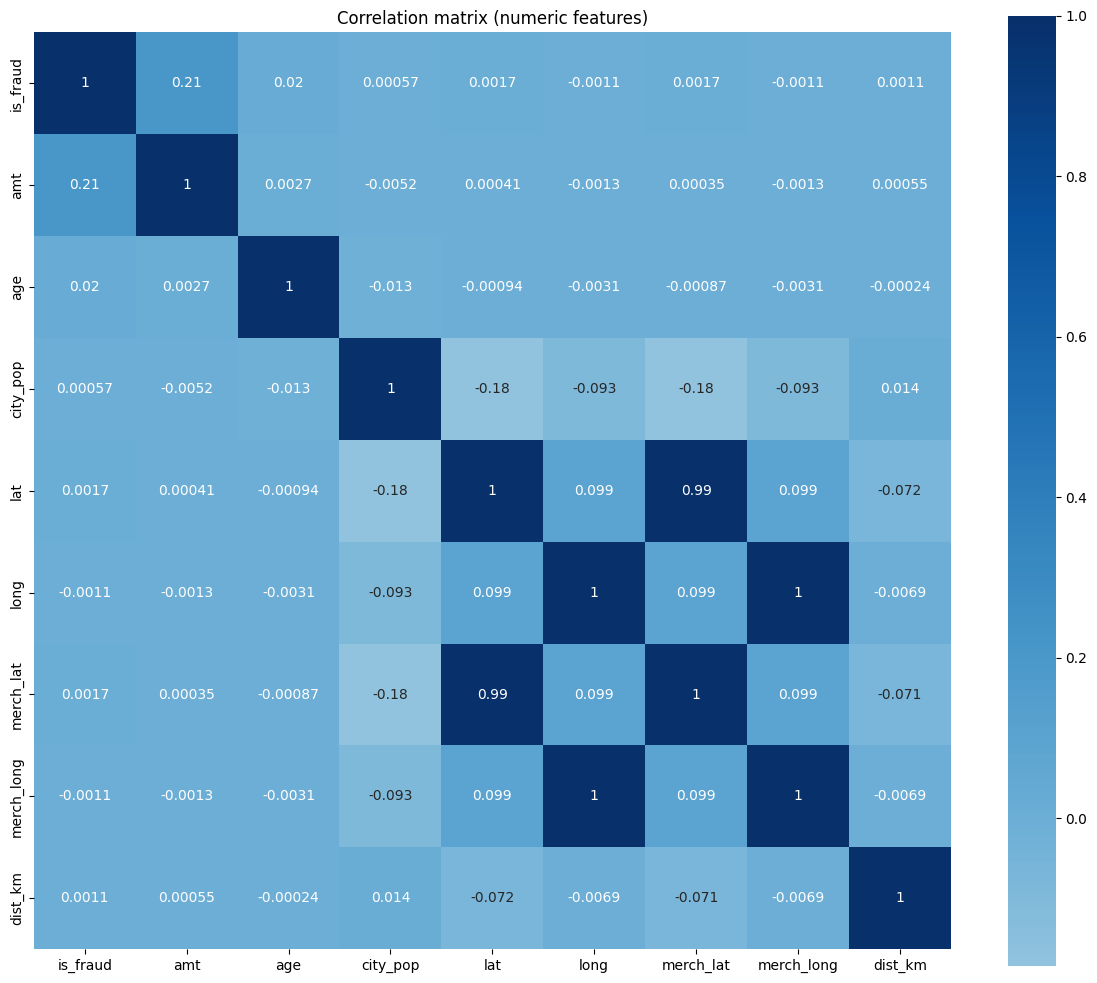

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
num_cols = [
    "is_fraud",
    "amt", "log_amt",
    "age",
    "city_pop", "log_city_pop",
    "lat", "long",
    "merch_lat", "merch_long",
    "dist_km",
    "hour", "dow", "month",
]
num_cols = [c for c in num_cols if c in df.columns]

drop_like_ids = [c for c in ["cc_num", "zip"] if c in num_cols]
for c in drop_like_ids:
    num_cols.remove(c)

corr_df = df[num_cols].copy()

corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="Blues", center=0, square=True)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

In [13]:
corr_with_fraud = corr["is_fraud"].drop("is_fraud").sort_values(key=lambda s: s.abs(), ascending=False)
corr_with_fraud

amt           0.205981
age           0.020031
lat           0.001732
merch_lat     0.001690
dist_km       0.001077
long         -0.001074
merch_long   -0.001060
city_pop      0.000571
Name: is_fraud, dtype: float64

Amount and age appear to have the highest correlation with fraud.
- higher amounts are more likely to be fraud
- age has a small effect, but still larger than the others

In [14]:
df.groupby("is_fraud")["amt"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,3459782.0,68.599819,162.324765,1.00,9.090,44.31,81.53,52941.23
1,19031.0,537.984062,393.814796,1.12,254.845,437.08,915.29,1403.41


Mean amount for fraud is substantilaly higher than non-fraud cases ($537.98 vs $68.60).

In [15]:
g = df.groupby("gender")["is_fraud"].agg(count="size", frauds="sum", fraud_rate="mean")
g["fraud_rate_%"] = (g["fraud_rate"]*100).round(3)
g

,count,frauds,fraud_rate,fraud_rate_%
gender,,,,
F,1812240,9602,0.005298,0.530
M,1666573,9429,0.005658,0.566


In [16]:
df["age_bin"] = pd.cut(df["age"], bins=[0,25,50,120], right=False)

age_rates = df.groupby("age_bin")["is_fraud"].agg(count="size", fraud_rate="mean")
age_rates["fraud_rate_%"] = (age_rates["fraud_rate"]*100).round(3)
age_rates

C:\Users\tyboo\AppData\Local\Temp\ipykernel_23168\3651202133.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rates = df.groupby("age_bin")["is_fraud"].agg(count="size", fraud_rate="mean")


,count,fraud_rate,fraud_rate_%
age_bin,,,
"[0, 25)",856310,0.004377,0.438
"[25, 50)",1717031,0.004590,0.459
"[50, 120)",905472,0.008174,0.817


Over 50 has a significant increase in risk of fraud

In [17]:
gender_age = df.pivot_table(index="age_bin", columns="gender", values="is_fraud", aggfunc="mean")
(gender_age*100).round(3)

C:\Users\tyboo\AppData\Local\Temp\ipykernel_23168\2895615357.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  gender_age = df.pivot_table(index="age_bin", columns="gender", values="is_fraud", aggfunc="mean")


gender,F,M
age_bin,,
"[0, 25)",0.413,0.465
"[25, 50)",0.429,0.493
"[50, 120)",0.856,0.780


For gender by age, Males age 0-50 are more likely, but after 50, Females are more likely to be victim of fraud.

C:\Users\tyboo\AppData\Local\Temp\ipykernel_23168\209272236.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = (df.groupby(["age_bin", "gender"])["is_fraud"]


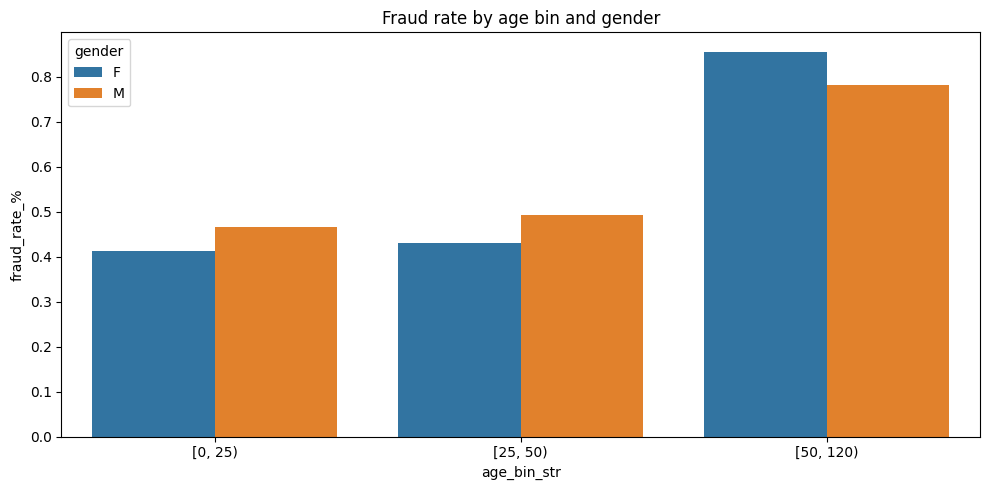

In [18]:
tmp = (df.groupby(["age_bin", "gender"])["is_fraud"]
         .mean()
         .reset_index())
tmp["fraud_rate_%"] = tmp["is_fraud"] * 100
tmp["age_bin_str"] = tmp["age_bin"].astype(str)

plt.figure(figsize=(10,5))
sns.barplot(data=tmp, x="age_bin_str", y="fraud_rate_%", hue="gender")
plt.xticks()
plt.title("Fraud rate by age bin and gender")
plt.tight_layout()
plt.show()

C:\Users\tyboo\AppData\Local\Temp\ipykernel_23168\3357298689.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d = (df.groupby("dist_bin")["is_fraud"]


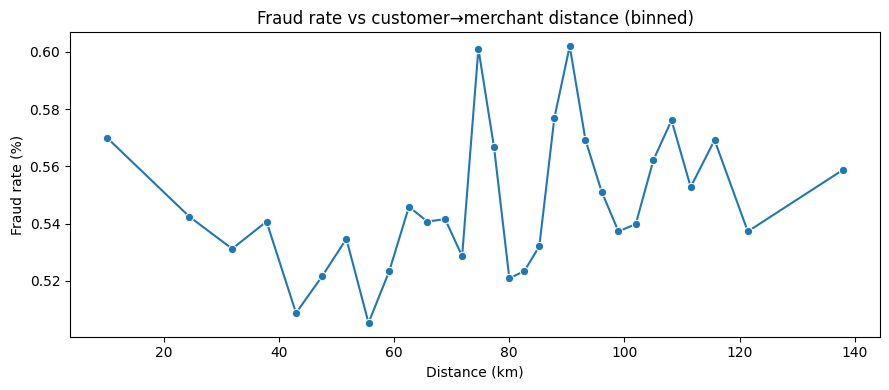

In [19]:
df["dist_bin"] = pd.qcut(df["dist_km"], q=30, duplicates="drop")
d = (df.groupby("dist_bin")["is_fraud"]
       .agg(count="size", fraud_rate="mean")
       .reset_index())

d["dist_mid"] = d["dist_bin"].apply(lambda x: (x.left + x.right) / 2)
d["fraud_rate_%"] = d["fraud_rate"] * 100

plt.figure(figsize=(9,4))
sns.lineplot(data=d, x="dist_mid", y="fraud_rate_%", marker="o")
plt.title("Fraud rate vs customer→merchant distance (binned)")
plt.xlabel("Distance (km)")
plt.ylabel("Fraud rate (%)")
plt.tight_layout()
plt.show()

In [20]:
state = (df.groupby("state")["is_fraud"]
           .agg(count="size", fraud_rate="mean")
           .query("count >= 1000")
           .sort_values("fraud_rate", ascending=False)
           .head(20))

(state.assign(fraud_rate_pct=lambda x: (x["fraud_rate"]*100).round(3)))

,count,fraud_rate,fraud_rate_pct
state,,,
ND,1479,0.014199,1.420
AK,1471,0.010877,1.088
ME,6623,0.010569,1.057
UT,21280,0.008459,0.846
SD,6611,0.008319,0.832
VT,3670,0.007629,0.763
DE,9516,0.007461,0.746
ID,14663,0.007093,0.709
OR,30777,0.007051,0.705


Note: Some states have less data available so the results of fraud rate could be potentially inaccurate.

In [23]:
df["amt_bin"] = pd.qcut(df["amt"], q=10, duplicates="drop")

rates = df.pivot_table(index="amt_bin", columns="age_bin", values="is_fraud", aggfunc="mean")
counts = df.pivot_table(index="amt_bin", columns="age_bin", values="is_fraud", aggfunc="size")

(rates * 100).round(3), counts

C:\Users\tyboo\AppData\Local\Temp\ipykernel_23168\4261784515.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rates = df.pivot_table(index="amt_bin", columns="age_bin", values="is_fraud", aggfunc="mean")
C:\Users\tyboo\AppData\Local\Temp\ipykernel_23168\4261784515.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts = df.pivot_table(index="amt_bin", columns="age_bin", values="is_fraud", aggfunc="size")


(age_bin             [0, 25)  [25, 50)  [50, 120)
 amt_bin                                         
 (0.999, 3.92]         0.000     0.001      0.004
 (3.92, 7.34]          0.075     0.072      0.124
 (7.34, 13.44]         0.543     0.585      0.893
 (13.44, 28.68]        0.322     0.494      0.302
 (28.68, 44.56]        0.000     0.000      0.000
 (44.56, 58.97]        0.000     0.002      0.018
 (58.97, 73.45]        0.000     0.000      0.000
 (73.45, 93.63]        0.001     0.002      0.001
 (93.63, 148.32]       0.166     0.164      0.052
 (148.32, 52941.23]    3.417     2.793      9.591,
 age_bin             [0, 25)  [25, 50)  [50, 120)
 amt_bin                                         
 (0.999, 3.92]         96219    158207      94353
 (3.92, 7.34]          96445    157525      93371
 (7.34, 13.44]         95032    161495      91025
 (13.44, 28.68]        87876    178669      81441
 (28.68, 44.56]        90086    182923      74953
 (44.56, 58.97]        92655    177218      78007

50+ individuals tend to have higher fraud rates across all amounts, and highest for large amounts by a lot.

Fraud rate increases with transaction amount across all ages.